# <span style="color:crimson; font-size:55px; font-family:'Times New Roman'">India Road Accidents Predictive Analysis</span>
<img src="bannerimg.jpg" width ="900">

***

# <span style="color:crimson; font-size:40px; font-family:'Times New Roman'">Project Objective :</span>
<span style="font-size:20px; font-family:'Times New Roman'">
The objective of this project is to analyze and predict patterns in road accidents across India having columns such as location (state, city), time (year, month, day, time of day), accident severity, vehicle and driver characteristics, road and weather conditions, and derived columns like casualty and fatality rates, with a goal of uncovering the key factors that contribute to accident severity and outcomes, such as casualties and fatalities, by examining variables like location, time, driver age, vehicle type, road and weather conditions, and traffic controls.</span>
<span style="color:indianred; font-size:20px; font-family:'Times New Roman'">The analysis aims to</span> 
<span style="font-size:20px; font-family:'Times New Roman'">identify patterns and trends in accidents across states, cities, and time periods.Highlight risk factors (e.g., alcohol involvement, speed limits, poor road conditions) that increase severity.Categorize vulnerable groups such as young drivers, certain vehicle types, or high‑risk locations.</span>


***

# <span style="color:crimson; font-size:35px; font-family:'Times New Roman'"> 1) Data Loading and Initial Overview</span>

***

# <span style="color:Darkcyan; font-size:25px; font-family:'Times New Roman'"> Import the dataset using Pandas :</span>

In [4]:
import pandas as pd
df = pd.read_excel("Accident prediction.xlsx")

***

# <span style="color:Darkcyan; font-size:25px; font-family:'Times New Roman'"> Number of rows and columns :</span>

In [13]:
print("Number of rows and columns :",df.shape)

Number of rows and columns : (3000, 22)


***

# <span style="color:Darkcyan; font-size:25px; font-family:'Times New Roman'"> Data types of each column :</span>

In [14]:
print(df.dtypes)

State Name                     object
City Name                      object
Year                            int64
Month                          object
Day of Week                    object
Time of Day                    object
Accident Severity              object
Number of Vehicles Involved     int64
Vehicle Type Involved          object
Number of Casualties            int64
Number of Fatalities            int64
Weather Conditions             object
Road Type                      object
Road Condition                 object
Lighting Conditions            object
Traffic Control Presence       object
Speed Limit (km/h)              int64
Driver Age                      int64
Driver Gender                  object
Driver License Status          object
Alcohol Involvement            object
Accident Location Details      object
dtype: object


***

# <span style="color:Darkcyan; font-size:25px; font-family:'Times New Roman'"> Initial Observations :</span>

In [15]:
df.head()

,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
0,Jammu and Kashmir,NaN,2021,May,Monday,01:46:00,Serious,5,Cycle,0,...,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2024,January,Wednesday,21:30:00,Minor,5,Truck,5,...,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,NaN,2023,May,Wednesday,05:37:00,Minor,5,Pedestrian,6,...,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,00:31:00,Minor,3,Bus,10,...,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,NaN,2021,August,Thursday,11:21:00,Minor,5,Cycle,7,...,Urban Road,Wet,Dusk,Signs,115,30,Male,NaN,No,Intersection


***

In [16]:
df.tail()

,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
2995,Tamil Nadu,Chennai,2022,January,Sunday,01:15:00,Minor,5,Truck,4,...,National Highway,Wet,Dark,Signs,74,43,Male,Expired,Yes,Intersection
2996,Uttarakhand,NaN,2024,July,Sunday,10:12:00,Fatal,3,Car,3,...,Urban Road,Under Construction,Daylight,NaN,86,23,Female,NaN,Yes,Intersection
2997,Meghalaya,NaN,2022,January,Thursday,19:34:00,Minor,2,Two-Wheeler,8,...,National Highway,Dry,Dark,Signs,47,57,Female,Valid,Yes,Intersection
2998,Meghalaya,NaN,2023,June,Sunday,20:54:00,Fatal,1,Cycle,9,...,Urban Road,Under Construction,Daylight,Signs,60,28,Female,Expired,Yes,Bridge
2999,Arunachal Pradesh,NaN,2020,September,Monday,07:19:00,Fatal,5,Cycle,1,...,National Highway,Under Construction,Daylight,NaN,40,66,Male,NaN,Yes,Bridge


***

In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   State Name                   3000 non-null   object
 1   City Name                    862 non-null    object
 2   Year                         3000 non-null   int64 
 3   Month                        3000 non-null   object
 4   Day of Week                  3000 non-null   object
 5   Time of Day                  3000 non-null   object
 6   Accident Severity            3000 non-null   object
 7   Number of Vehicles Involved  3000 non-null   int64 
 8   Vehicle Type Involved        3000 non-null   object
 9   Number of Casualties         3000 non-null   int64 
 10  Number of Fatalities         3000 non-null   int64 
 11  Weather Conditions           3000 non-null   object
 12  Road Type                    3000 non-null   object
 13  Road Condition               3000

***

In [18]:
df.describe()

,Year,Number of Vehicles Involved,Number of Casualties,Number of Fatalities,Speed Limit (km/h),Driver Age
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000
mean,2022.182333,2.996000,5.066000,2.455333,74.940667,44.17700
std,2.106474,1.428285,3.214097,1.717650,26.765088,15.40286
min,2019.000000,1.000000,0.000000,0.000000,30.000000,18.00000
25%,2020.000000,2.000000,2.000000,1.000000,51.000000,31.00000
50%,2022.000000,3.000000,5.000000,2.000000,75.000000,45.00000
75%,2024.000000,4.000000,8.000000,4.000000,99.000000,57.00000
max,2025.000000,5.000000,10.000000,5.000000,120.000000,70.00000


***

In [19]:
df.describe(include='object')

,State Name,City Name,Month,Day of Week,Time of Day,Accident Severity,Vehicle Type Involved,Weather Conditions,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
count,3000,862,3000,3000,3000,3000,3000,3000,3000,3000,3000,2284,3000,2025,3000,3000
unique,32,27,12,7,1263,3,7,5,4,4,4,3,2,2,2,4
top,Goa,New Delhi,March,Wednesday,08:34:00,Minor,Truck,Rainy,State Highway,Under Construction,Dark,Signs,Female,Valid,Yes,Intersection
freq,109,39,266,468,7,1034,449,631,771,778,763,812,1563,1057,1520,789


***

# <span style="color:crimson; font-size:35px; font-family:'Times New Roman'"> 2) Data Pre-processing</span>

***

# <span style="color:Darkcyan; font-size:25px; font-family:'Times New Roman'">Number of missing values:</span>

In [20]:
print(df.isnull().sum())

State Name                        0
City Name                      2138
Year                              0
Month                             0
Day of Week                       0
Time of Day                       0
Accident Severity                 0
Number of Vehicles Involved       0
Vehicle Type Involved             0
Number of Casualties              0
Number of Fatalities              0
Weather Conditions                0
Road Type                         0
Road Condition                    0
Lighting Conditions               0
Traffic Control Presence        716
Speed Limit (km/h)                0
Driver Age                        0
Driver Gender                     0
Driver License Status           975
Alcohol Involvement               0
Accident Location Details         0
dtype: int64


***

In [21]:
print(df.isna().sum())

State Name                        0
City Name                      2138
Year                              0
Month                             0
Day of Week                       0
Time of Day                       0
Accident Severity                 0
Number of Vehicles Involved       0
Vehicle Type Involved             0
Number of Casualties              0
Number of Fatalities              0
Weather Conditions                0
Road Type                         0
Road Condition                    0
Lighting Conditions               0
Traffic Control Presence        716
Speed Limit (km/h)                0
Driver Age                        0
Driver Gender                     0
Driver License Status           975
Alcohol Involvement               0
Accident Location Details         0
dtype: int64


***

# <span style="color:Darkcyan; font-size:25px; font-family:'Times New Roman'"> Handling missing values :</span>

In [22]:
df['City Name']=df['City Name'].fillna('Unknown')
df['Traffic Control Presence'] = df['Traffic Control Presence'].fillna(df['Traffic Control Presence'].mode()[0])
df['Driver License Status']=df['Driver License Status'].fillna('No License')

In [23]:
print(df.isnull().sum())

State Name                     0
City Name                      0
Year                           0
Month                          0
Day of Week                    0
Time of Day                    0
Accident Severity              0
Number of Vehicles Involved    0
Vehicle Type Involved          0
Number of Casualties           0
Number of Fatalities           0
Weather Conditions             0
Road Type                      0
Road Condition                 0
Lighting Conditions            0
Traffic Control Presence       0
Speed Limit (km/h)             0
Driver Age                     0
Driver Gender                  0
Driver License Status          0
Alcohol Involvement            0
Accident Location Details      0
dtype: int64


***

# <span style="color:Darkcyan; font-size:25px; font-family:'Times New Roman'">Replacing a name in one column to another :</span>

In [24]:
df['Traffic Control Presence'] = df['Traffic Control Presence'].replace('Signs', 'Signboard')

***

# <span style="color:Darkcyan; font-size:25px; font-family:'Times New Roman'"> Removing duplicates :</span>

In [25]:
df.duplicated().sum()

np.int64(0)

***

# <span style="color:Darkcyan; font-size:25px; font-family:'Times New Roman'"> Creating derived columns :</span>

In [26]:
df['Casualty_Rate'] = df['Number of Casualties'] / df['Number of Vehicles Involved']
(df) ## Shows how severe each accident was relative to vehicles involved.

,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details,Casualty_Rate
0,Jammu and Kashmir,Unknown,2021,May,Monday,01:46:00,Serious,5,Cycle,0,...,Wet,Dark,Signboard,61,66,Male,No License,Yes,Curve,0.000000
1,Uttar Pradesh,Lucknow,2024,January,Wednesday,21:30:00,Minor,5,Truck,5,...,Dry,Dusk,Signboard,92,60,Male,No License,Yes,Straight Road,1.000000
2,Chhattisgarh,Unknown,2023,May,Wednesday,05:37:00,Minor,5,Pedestrian,6,...,Under Construction,Dawn,Signboard,120,26,Female,No License,No,Bridge,1.200000
3,Uttar Pradesh,Lucknow,2020,June,Saturday,00:31:00,Minor,3,Bus,10,...,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road,3.333333
4,Sikkim,Unknown,2021,August,Thursday,11:21:00,Minor,5,Cycle,7,...,Wet,Dusk,Signboard,115,30,Male,No License,No,Intersection,1.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Tamil Nadu,Chennai,2022,January,Sunday,01:15:00,Minor,5,Truck,4,...,Wet,Dark,Signboard,74,43,Male,Expired,Yes,Intersection,0.800000
2996,Uttarakhand,Unknown,2024,July,Sunday,10:12:00,Fatal,3,Car,3,...,Under Construction,Daylight,Signboard,86,23,Female,No License,Yes,Intersection,1.000000
2997,Meghalaya,Unknown,2022,January,Thursday,19:34:00,Minor,2,Two-Wheeler,8,...,Dry,Dark,Signboard,47,57,Female,Valid,Yes,Intersection,4.000000
2998,Meghalaya,Unknown,2023,June,Sunday,20:54:00,Fatal,1,Cycle,9,...,Under Construction,Daylight,Signboard,60,28,Female,Expired,Yes,Bridge,9.000000


***

In [27]:
df['Fatality_Rate'] = df['Number of Fatalities'] / df['Number of Vehicles Involved']
(df)  ##  calculate fatality rate per vehicle to normalize accident severity by the number of vehicles 
      ##involved, making it easier to compare how deadly each accident was regardless of its scale.

,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details,Casualty_Rate,Fatality_Rate
0,Jammu and Kashmir,Unknown,2021,May,Monday,01:46:00,Serious,5,Cycle,0,...,Dark,Signboard,61,66,Male,No License,Yes,Curve,0.000000,0.800000
1,Uttar Pradesh,Lucknow,2024,January,Wednesday,21:30:00,Minor,5,Truck,5,...,Dusk,Signboard,92,60,Male,No License,Yes,Straight Road,1.000000,0.800000
2,Chhattisgarh,Unknown,2023,May,Wednesday,05:37:00,Minor,5,Pedestrian,6,...,Dawn,Signboard,120,26,Female,No License,No,Bridge,1.200000,1.000000
3,Uttar Pradesh,Lucknow,2020,June,Saturday,00:31:00,Minor,3,Bus,10,...,Dark,Signals,76,34,Female,Valid,Yes,Straight Road,3.333333,1.666667
4,Sikkim,Unknown,2021,August,Thursday,11:21:00,Minor,5,Cycle,7,...,Dusk,Signboard,115,30,Male,No License,No,Intersection,1.400000,0.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Tamil Nadu,Chennai,2022,January,Sunday,01:15:00,Minor,5,Truck,4,...,Dark,Signboard,74,43,Male,Expired,Yes,Intersection,0.800000,0.600000
2996,Uttarakhand,Unknown,2024,July,Sunday,10:12:00,Fatal,3,Car,3,...,Daylight,Signboard,86,23,Female,No License,Yes,Intersection,1.000000,0.000000
2997,Meghalaya,Unknown,2022,January,Thursday,19:34:00,Minor,2,Two-Wheeler,8,...,Dark,Signboard,47,57,Female,Valid,Yes,Intersection,4.000000,2.500000
2998,Meghalaya,Unknown,2023,June,Sunday,20:54:00,Fatal,1,Cycle,9,...,Daylight,Signboard,60,28,Female,Expired,Yes,Bridge,9.000000,2.000000


***

In [28]:
df["Total_Impact"] = df["Number of Casualties"] + df["Number of Fatalities"]
df

,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details,Casualty_Rate,Fatality_Rate,Total_Impact
0,Jammu and Kashmir,Unknown,2021,May,Monday,01:46:00,Serious,5,Cycle,0,...,Signboard,61,66,Male,No License,Yes,Curve,0.000000,0.800000,4
1,Uttar Pradesh,Lucknow,2024,January,Wednesday,21:30:00,Minor,5,Truck,5,...,Signboard,92,60,Male,No License,Yes,Straight Road,1.000000,0.800000,9
2,Chhattisgarh,Unknown,2023,May,Wednesday,05:37:00,Minor,5,Pedestrian,6,...,Signboard,120,26,Female,No License,No,Bridge,1.200000,1.000000,11
3,Uttar Pradesh,Lucknow,2020,June,Saturday,00:31:00,Minor,3,Bus,10,...,Signals,76,34,Female,Valid,Yes,Straight Road,3.333333,1.666667,15
4,Sikkim,Unknown,2021,August,Thursday,11:21:00,Minor,5,Cycle,7,...,Signboard,115,30,Male,No License,No,Intersection,1.400000,0.200000,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Tamil Nadu,Chennai,2022,January,Sunday,01:15:00,Minor,5,Truck,4,...,Signboard,74,43,Male,Expired,Yes,Intersection,0.800000,0.600000,7
2996,Uttarakhand,Unknown,2024,July,Sunday,10:12:00,Fatal,3,Car,3,...,Signboard,86,23,Female,No License,Yes,Intersection,1.000000,0.000000,3
2997,Meghalaya,Unknown,2022,January,Thursday,19:34:00,Minor,2,Two-Wheeler,8,...,Signboard,47,57,Female,Valid,Yes,Intersection,4.000000,2.500000,13
2998,Meghalaya,Unknown,2023,June,Sunday,20:54:00,Fatal,1,Cycle,9,...,Signboard,60,28,Female,Expired,Yes,Bridge,9.000000,2.000000,11


In [29]:
print(df.dtypes)

State Name                      object
City Name                       object
Year                             int64
Month                           object
Day of Week                     object
Time of Day                     object
Accident Severity               object
Number of Vehicles Involved      int64
Vehicle Type Involved           object
Number of Casualties             int64
Number of Fatalities             int64
Weather Conditions              object
Road Type                       object
Road Condition                  object
Lighting Conditions             object
Traffic Control Presence        object
Speed Limit (km/h)               int64
Driver Age                       int64
Driver Gender                   object
Driver License Status           object
Alcohol Involvement             object
Accident Location Details       object
Casualty_Rate                  float64
Fatality_Rate                  float64
Total_Impact                     int64
dtype: object


***

# <span style="color:Darkcyan; font-size:30px; font-family:'Times New Roman'"> Filtering or aggregating data :</span>

# <span style="color:GoldenRod; font-size:25px; font-family:'Times New Roman'"> 1) Filter accidents in a specific state :</span>

In [30]:

kerala_accidents = df[df['State Name'] == 'Kerala'].reset_index()
# Select only the required columns
kerala_accidents = kerala_accidents[['State Name',
                                     'Accident Severity',
                                     'Vehicle Type Involved',
                                     'Number of Casualties',
                                     'Number of Fatalities']]

(kerala_accidents)

,State Name,Accident Severity,Vehicle Type Involved,Number of Casualties,Number of Fatalities
0,Kerala,Fatal,Car,3,1
1,Kerala,Minor,Two-Wheeler,10,3
2,Kerala,Fatal,Cycle,9,3
3,Kerala,Serious,Two-Wheeler,10,4
4,Kerala,Serious,Pedestrian,10,0
...,...,...,...,...,...
97,Kerala,Serious,Auto-Rickshaw,9,4
98,Kerala,Fatal,Truck,1,5
99,Kerala,Serious,Truck,9,4
100,Kerala,Fatal,Bus,8,4


***

# <span style="color:GoldenRod; font-size:25px; font-family:'Times New Roman'"> 2) Accidents with fatalities :</span>

In [31]:
fatal_accidents = df[df['Number of Fatalities'] > 0]
# Count how many such accidents exist
print("Number of accidents with fatalities:", fatal_accidents.shape[0])

Number of accidents with fatalities: 2470


***

# <span style="color:GoldenRod; font-size:25px; font-family:'Times New Roman'">3) Accidents involving alcohol :</span>

In [32]:
alcohol_accidents = df[df['Alcohol Involvement'] == 'Yes'].reset_index()
alcohol_accidents = alcohol_accidents[['State Name',
                                       'Accident Severity',
                                       'Number of Casualties',
                                       'Number of Fatalities',
                                       'Road Type',
                                       'Driver Age',
                                       'Driver Gender']]
(alcohol_accidents)

,State Name,Accident Severity,Number of Casualties,Number of Fatalities,Road Type,Driver Age,Driver Gender
0,Jammu and Kashmir,Serious,0,4,National Highway,66,Male
1,Uttar Pradesh,Minor,5,4,Urban Road,60,Male
2,Uttar Pradesh,Minor,10,5,State Highway,34,Female
3,Meghalaya,Serious,6,2,Village Road,44,Male
4,Rajasthan,Fatal,3,2,State Highway,50,Female
...,...,...,...,...,...,...,...
1515,Tamil Nadu,Minor,4,3,National Highway,43,Male
1516,Uttarakhand,Fatal,3,0,Urban Road,23,Female
1517,Meghalaya,Minor,8,5,National Highway,57,Female
1518,Meghalaya,Fatal,9,2,Urban Road,28,Female


***

# <span style="color:GoldenRod; font-size:25px; font-family:'Times New Roman'">4) Young drivers making accidents :</span>

In [33]:
young_driver_stats = df[df['Driver Age'] < 25].groupby('Driver Gender').agg(
    Number_of_Accidents = ('Driver Age','count'),
    Total_Casualties = ('Number of Casualties','sum'),
    Total_Fatalities = ('Number of Fatalities','sum')
).reset_index()

(young_driver_stats)

,Driver Gender,Number_of_Accidents,Total_Casualties,Total_Fatalities
0,Female,222,1128,533
1,Male,195,1022,476


***

# <span style="color:GoldenRod; font-size:25px; font-family:'Times New Roman'">5) Total accidents per state :</span>

In [34]:
accidents_per_state = df.groupby('State Name').size().reset_index(name='Accident Count')
(accidents_per_state)

,State Name,Accident Count
0,Andhra Pradesh,88
1,Arunachal Pradesh,79
2,Assam,91
3,Bihar,78
4,Chandigarh,82
5,Chhattisgarh,92
6,Delhi,108
7,Goa,109
8,Gujarat,100
9,Haryana,94


***

# <span style="color:GoldenRod; font-size:25px; font-family:'Times New Roman'">6) Average casualties per city :</span>

In [35]:
avg_casualties_city = df.groupby('City Name')['Number of Casualties'].mean().reset_index()
(avg_casualties_city)

,City Name,Number of Casualties
0,Ahmedabad,6.200000
1,Bangalore,5.655172
2,Chennai,4.468750
3,Coimbatore,5.351351
4,Durgapur,4.892857
5,Dwarka,6.000000
6,Jaipur,5.370370
7,Jodhpur,5.161290
8,Kanpur,4.357143
9,Kolkata,4.709677


***

# <span style="color:GoldenRod; font-size:25px; font-family:'Times New Roman'">7) Fatalities by year :</span>

In [36]:
fatalities_year = df.groupby('Year')['Number of Fatalities'].sum().reset_index()
(fatalities_year)

,Year,Number of Fatalities
0,2019,1146
1,2020,1326
2,2021,5
3,2022,1329
4,2023,1170
5,2024,1145
6,2025,1245


***

# <span style="color:GoldenRod; font-size:25px; font-family:'Times New Roman'">8) Severity distribution by road type :</span>

In [19]:
severity_road = df.groupby(['Road Type','Accident Severity']).size().reset_index(name='Count')
(severity_road)

,Road Type,Accident Severity,Count
0,National Highway,Fatal,242
1,National Highway,Minor,248
2,National Highway,Serious,259
3,State Highway,Fatal,261
4,State Highway,Minor,252
5,State Highway,Serious,258
6,Urban Road,Fatal,254
7,Urban Road,Minor,252
8,Urban Road,Serious,206
9,Village Road,Fatal,228


***

# <span style="color:GoldenRod; font-size:25px; font-family:'Times New Roman'">9) Casualty, fatality rate by weather condition :</span>

In [38]:
casualty_weather = df.groupby('Weather Conditions')[['Casualty_Rate', 'Fatality_Rate']].mean().reset_index()
(casualty_weather)

,Weather Conditions,Casualty_Rate,Fatality_Rate
0,Clear,2.193351,1.091318
1,Foggy,2.269676,1.068663
2,Hazy,2.481168,1.168942
3,Rainy,2.379081,1.185790
4,Stormy,2.304310,1.016258


***

# <span style="color:GoldenRod; font-size:25px; font-family:'Times New Roman'">10) Accidents by month and severity :</span>

In [39]:
monthly_severity = df.groupby(['Month','Accident Severity']).size().reset_index(name='Accident_Count')
(monthly_severity)

,Month,Accident Severity,Accident_Count
0,April,Fatal,82
1,April,Minor,76
2,April,Serious,78
3,August,Fatal,79
4,August,Minor,87
5,August,Serious,81
6,December,Fatal,79
7,December,Minor,97
8,December,Serious,84
9,February,Fatal,80


***

# <span style="color:GoldenRod; font-size:25px; font-family:'Times New Roman'">11) Accidents by day of week :</span>

In [40]:
accidents_day = df.groupby('Day of Week').size().reset_index(name='Accident_Count')
(accidents_day)

,Day of Week,Accident_Count
0,Friday,423
1,Monday,427
2,Saturday,419
3,Sunday,423
4,Thursday,438
5,Tuesday,402
6,Wednesday,468


***

# <span style="color:GoldenRod; font-size:25px; font-family:'Times New Roman'">12) Accidents by traffic control presence :</span>

In [41]:
traffic_control = df.groupby('Traffic Control Presence').size().reset_index(name='Accident_Count')
(traffic_control)

,Traffic Control Presence,Accident_Count
0,Police Checkpost,736
1,Signals,736
2,Signboard,1528


***

# <span style="color:GoldenRod; font-size:25px; font-family:'Times New Roman'">13)  Frequency Counts :</span>

In [42]:
severity_counts = df['Accident Severity'].value_counts().reset_index()
(severity_counts)


,Accident Severity,count
0,Minor,1034
1,Fatal,985
2,Serious,981


In [43]:
weather_counts = df['Weather Conditions'].value_counts().reset_index()
(weather_counts)

,Weather Conditions,count
0,Rainy,631
1,Stormy,611
2,Hazy,608
3,Foggy,576
4,Clear,574


In [23]:
road_counts= (df['Road Type'].value_counts().reset_index())
(road_counts)

,Road Type,count
0,State Highway,771
1,Village Road,768
2,National Highway,749
3,Urban Road,712


***

# <span style="color:brown; font-size:30px; font-family:'Times New Roman'"> 3. Exploratory Data Analysis (EDA)</span>

# <span style="color:Darkcyan; font-size:30px; font-family:'Times New Roman'">1. Univariate Analysis :</span>

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# <span style="color:navy; font-size:25px; font-family:'Times New Roman'">Accident Severity Distribution :</span>
<img src="C:\Users\menon\Downloads\1.jpg" style="width:380px;height:200px"/>


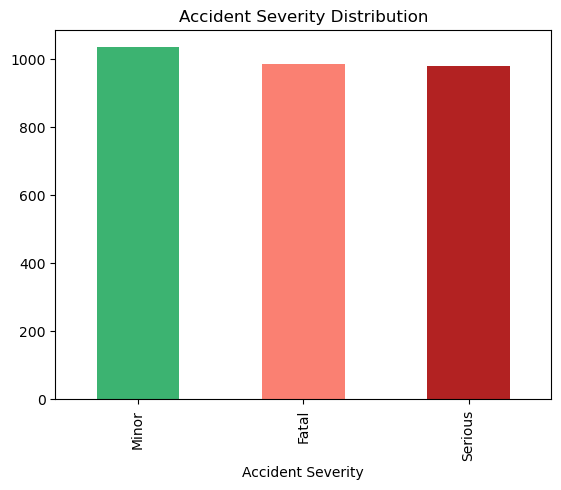

In [9]:
colors = ['MediumSeaGreen', 'Salmon', 'FireBrick']
df['Accident Severity'].value_counts().plot(
    kind='bar',
    title='Accident Severity Distribution',
    color=colors
)
plt.show()



# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Minor accidents are the most common in this, but serious and fatal accidents occur at nearly the same frequency.This means that while most crashes don’t result in severe outcomes, the proportion of high‑severity accidents is still significant enough to demand attention.</span>




***

# <span style="color:navy; font-size:25px; font-family:'Times New Roman'">Driver Age Distribution :</span>
<img src="C:\Users\menon\Downloads\14.jpg" style="width:300px;height:200px"/>

C:\Users\menon\AppData\Local\Temp\ipykernel_21164\3130958264.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Driver Age'], shade=True,color='mediumseagreen')


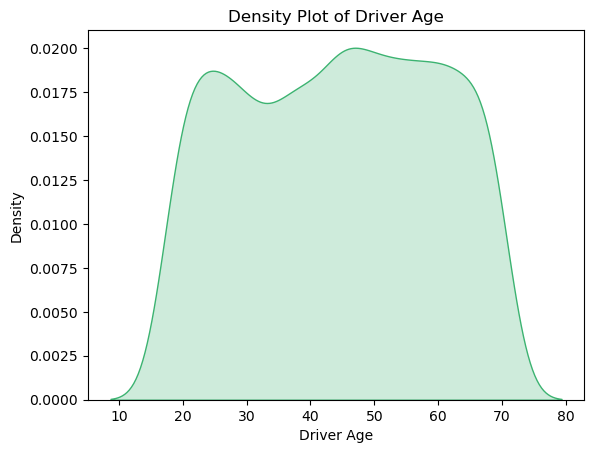

In [47]:
sns.kdeplot(df['Driver Age'], shade=True,color='mediumseagreen')
plt.title("Density Plot of Driver Age")
plt.xlabel("Driver Age")
plt.ylabel("Density")
plt.show()


# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Accidents happen across all age groups, but there are clear peaks among younger drivers (around 20–30 years) and middle‑aged drivers (around 50 years).This means that both inexperienced younger drivers and more experienced middle‑aged drivers are noticeably more involved in accidents compared to other age ranges.</span>


***

# <span style="color:navy; font-size:25px; font-family:'Times New Roman'">Speed Limit Distribution :</span>

<img src="C:/Users/menon/Downloads/7.jpg" width ="200">

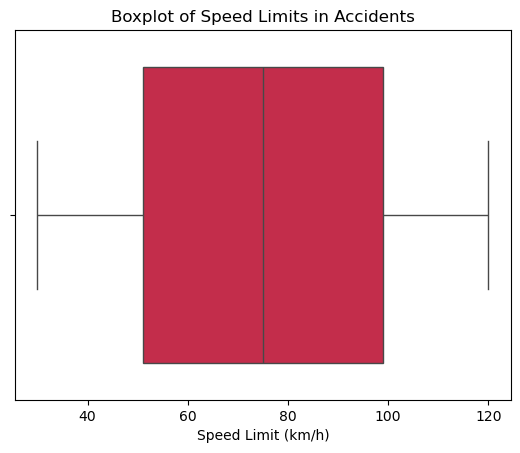

In [48]:
sns.boxplot(x=df['Speed Limit (km/h)'], color='Crimson') 
plt.title("Boxplot of Speed Limits in Accidents") 
plt.xlabel("Speed Limit (km/h)") 
plt.show() 

# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Most accidents occur at moderate speed limits, with the central range clustering between about 50 km/h and 80 km/h. The median lies in this band, while the whiskers show that accidents also happen at both lower (around 30–40 km/h) and higher speed limits (above 100 km/h).This means that crashes are not limited to extreme speeds—both everyday city driving speeds and highway speeds contribute significantly.
</span>


***

# <span style="color:navy; font-size:25px; font-family:'Times New Roman'">Vehicles Involved :</span>

<img src="C:/Users/menon/Downloads/OIP.jpg" width ="900">

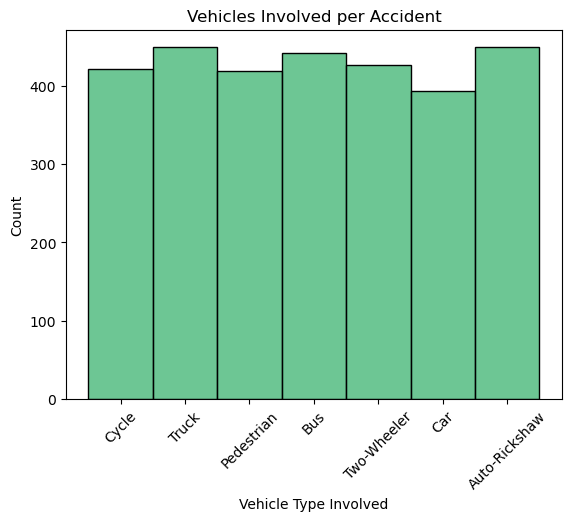

In [10]:
sns.histplot(df['Vehicle Type Involved'], bins=10, color='mediumseagreen')
plt.title("Vehicles Involved per Accident")
plt.xticks(rotation=45)
plt.show()


# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Accidents are fairly evenly distributed across different vehicle types, but trucks, buses, and auto‑rickshaws show slightly higher counts compared to others.While all vehicle categories contribute to accidents, larger vehicles and public transport modes (like buses and auto‑rickshaws) may pose a relatively higher risk, possibly due to their frequent use and greater exposure on the roads.</span>



***

# <span style="color:navy; font-size:25px; font-family:'Times New Roman'">Accident Distribution by Driver Gender :</span>
<img src="C:\Users\menon\Downloads\16.jpg" style="width:400px;height:200px"/>

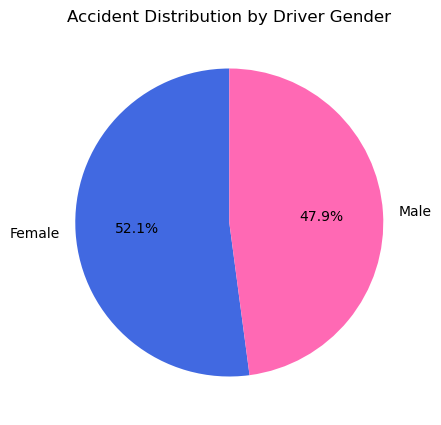

In [55]:
plt.figure(figsize=(5,5))
gender_counts = df['Driver Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
colors=['royalblue','hotpink'], startangle=90)
plt.title("Accident Distribution by Driver Gender")
plt.show()

# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">The accident distribution between male and female drivers is almost equal,female drivers slightly higher (52.1%) than male drivers (47.9%).This suggests that accidents are not strongly linked toward a single gender, indicating that road safety risks affect both male and female drivers nearly equally.</span>

***

 # <span style="color:navy; font-size:25px; font-family:'Times New Roman'">Fatalities Distribution :</span>
 <img src="C:\Users\menon\Downloads\18.jpg" style="width:240px;height:200px"/>

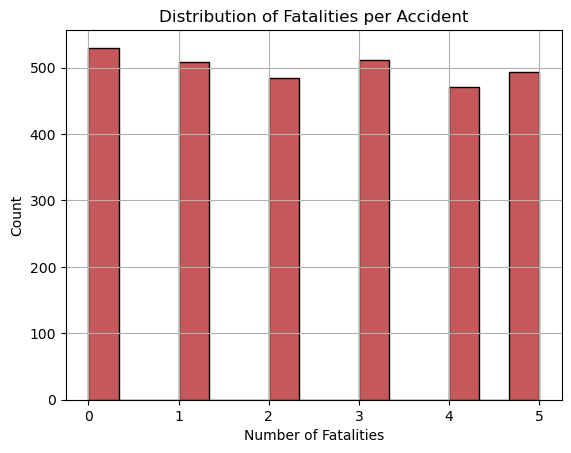

In [6]:
sns.histplot(df['Number of Fatalities'], bins=15, color='firebrick')
plt.title("Distribution of Fatalities per Accident")
plt.grid('True')
plt.show()


# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Most accidents result in zero fatalities, while a much smaller proportion involve one or more deaths. The sharp drop after the “0 fatalities” bar shows that fatal accidents are relatively rare compared to non‑fatal ones.This highlights that while accidents are frequent, the majority are not deadly.</span> 


***

# <span style="color:Darkcyan; font-size:30px; font-family:'Times New Roman'">2) Bivariate Analysis :</span>

# <span style="color:olive; font-size:25px; font-family:'Times New Roman'">Severity vs Vehicle Type :</span>
<img src="C:\Users\menon\Downloads\19.jpg" style="width:500px;height:200px"/>

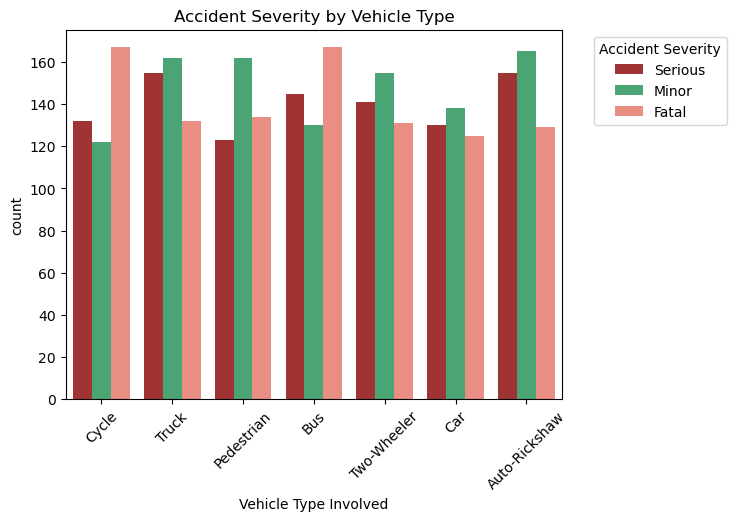

In [57]:
colors = ['FireBrick','MediumSeaGreen', 'Salmon']
sns.countplot(x='Vehicle Type Involved', hue='Accident Severity', data=df,palette=colors)
plt.title("Accident Severity by Vehicle Type")
plt.xticks(rotation=45)
plt.legend(title='Accident Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Serious accidents are slightly more common across most vehicle types, while minor and fatal accidents occur at nearly similar levels. This means that regardless of whether it’s a car, bus, truck, or two‑wheeler, the risk of a serious crash is consistently high.</span>



***

# <span style="color:olive; font-size:25px; font-family:'Times New Roman'">Casualties by Road Type :</span>
<img src="C:\Users\menon\Downloads\20.jpg" style="width:500px;height:200px"/>

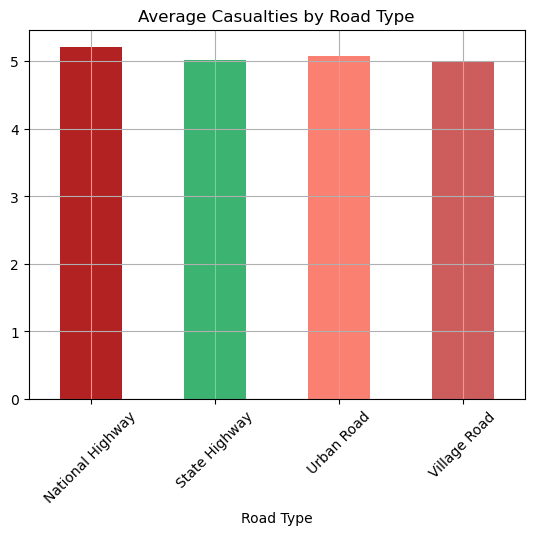

In [58]:
colors = ['FireBrick','MediumSeaGreen', 'Salmon','indianred']
df.groupby('Road Type')['Number of Casualties'].mean().plot(kind='bar', color=colors)
plt.title("Average Casualties by Road Type")
plt.grid('True')
plt.xticks(rotation=45)
plt.show()


# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">National Highways have the highest average casualties per accident, while Village Roads have the lowest. Urban Roads and State Highways fall in between, with Urban Roads showing slightly higher averages than State Highways.Major, high‑traffic roads like National Highways and Urban Roads have greater risks for severe accidents, due to higher speeds and heavy traffic, whereas Village Roads have fewer casualties.
</span>


***

# <span style="color:olive; font-size:25px; font-family:'Times New Roman'"> Fatalities by Year :</span>
<img src="C:\Users\menon\Downloads\26.jpg" style="width:500px;height:150px"/>

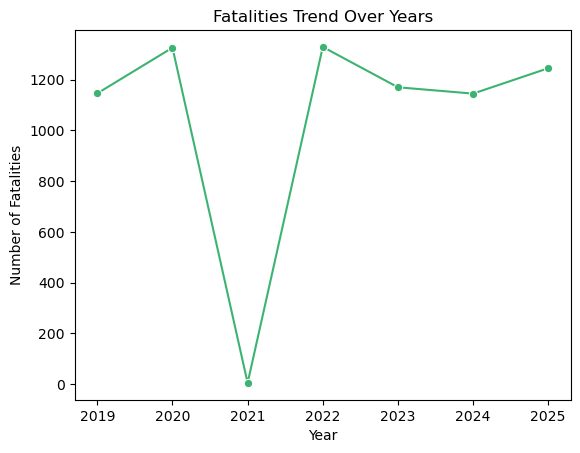

In [59]:
sns.lineplot(x='Year', y='Number of Fatalities', data=fatalities_year, marker='o',color='MediumSeaGreen')
plt.title("Fatalities Trend Over Years")
plt.show()

# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Fatalities dropped sharply in 2021, then spiked again in 2022, and have remained relatively stable from 2023 to 2025.This indicates that something unusual happened in 2021 to reduce fatalities—possibly reduced traffic or stricter safety measures have been taken as actions to reduce fatalities and after that fatalities have settled into a consistent range.But still it is at a relatively high level compared to the dip.</span>


***

# <span style="color:olive; font-size:25px; font-family:'Times New Roman'">Traffic Control Presence :</span>
<img src="C:\Users\menon\Downloads\23.jpg" style="width:200px;height:150px"/>

C:\Users\menon\AppData\Local\Temp\ipykernel_21164\3060445897.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Traffic Control Presence', y='Accident_Count', data=traffic_control,palette=['firebrick', 'green','gold'])


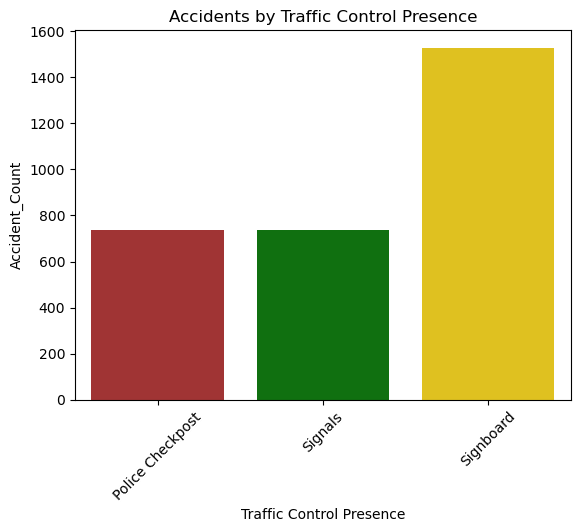

In [60]:
sns.barplot(x='Traffic Control Presence', y='Accident_Count', data=traffic_control,palette=['firebrick', 'green','gold'])
plt.title("Accidents by Traffic Control Presence")
plt.xticks(rotation=45)
plt.show()

# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Signboards are linked with the highest number of accidents compared to police checkposts and signals. Both police checkposts and signals show similar accident counts, but signboards stand out with more than double the accidents.This suggests that static signboards may be less effective at preventing accidents than active controls like signals or police presence.</span>


***

# <span style="color:olive; font-size:25px; font-family:'Times New Roman'">Speed Limit vs. Accident Severity :</span>
<img src="C:\Users\menon\Downloads\24.jpg" style="width:250px;height:200px"/>

C:\Users\menon\AppData\Local\Temp\ipykernel_21164\3938327874.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Accident Severity', y='Speed Limit (km/h)',


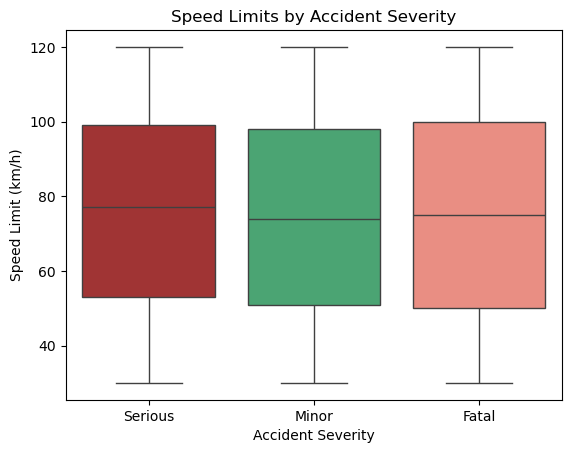

In [61]:
sns.boxplot(x='Accident Severity', y='Speed Limit (km/h)',
data=df, palette=['FireBrick','MediumSeaGreen', 'Salmon'])
plt.title("Speed Limits by Accident Severity")
plt.show()

# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Higher speed limits are more often associated with serious and fatal accidents compared to minor ones. Accident severity tends to increase with higher speed limits.</span>

***

# <span style="color:olive; font-size:25px; font-family:'Times New Roman'">Alcohol Involvement :</span>
<img src="C:\Users\menon\Downloads\30.jpg" style="width:350px;height:200px"/>

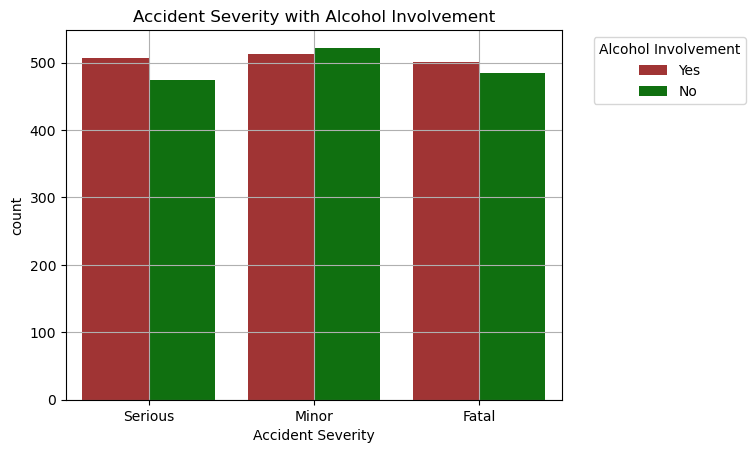

In [30]:
sns.countplot(x='Accident Severity', hue='Alcohol Involvement', data=df,palette=['firebrick', 'green'])
plt.legend(title='Alcohol Involvement', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid('True')
plt.title("Accident Severity with Alcohol Involvement")
plt.show()

# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Alcohol involvement increases the chances of serious and fatal accidents, while minor accidents are slightly more common when alcohol is not involved. This means alcohol plays a significant role in making accidents more severe,therefore strict actions to be taken against the consumption of alcohol during driving.</span>


***

# <span style="color:olive; font-size:25px; font-family:'Times New Roman'">Driver Age vs. Number of Fatalities :</span>
<img src="C:\Users\menon\Downloads\32.jpg" style="width:450px;height:200px"/>

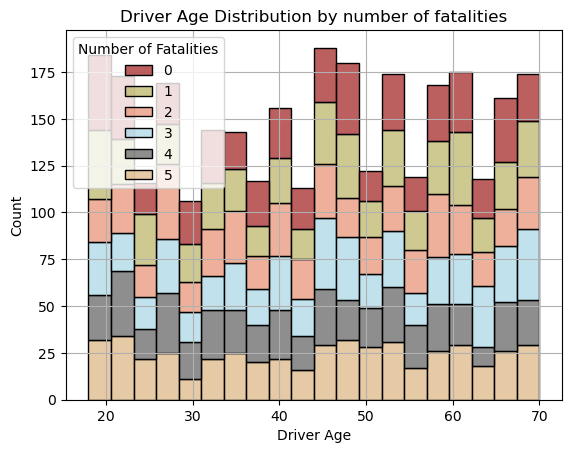

In [63]:
sns.histplot(data=df, x='Driver Age', hue='Number of Fatalities',
             multiple='stack', bins=20, palette=['brown','darkkhaki','darkSalmon','lightblue','dimgray','burlywood'])
plt.title("Driver Age Distribution by number of fatalities")
plt.grid('True')
plt.show()


# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Fatalities occur across all driver age groups, but younger and middle‑aged drivers show slightly higher counts compared to older drivers. The stacked bars make it clear that while most accidents result in zero or one fatality, there are still cases of multiple fatalities spread across ages.No age group is completely safe from fatal accidents, but the risk seems a bit more concentrated among drivers in their 20s to 40s.</span>


***

# <span style="color:olive; font-size:25px; font-family:'Times New Roman'">Driver Age vs. Accident Severity :</span>
<img src="C:\Users\menon\Downloads\33.jpg" style="width:450px;height:200px"/>

C:\Users\menon\AppData\Local\Temp\ipykernel_21164\556596075.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Accident Severity', y='Driver Age',


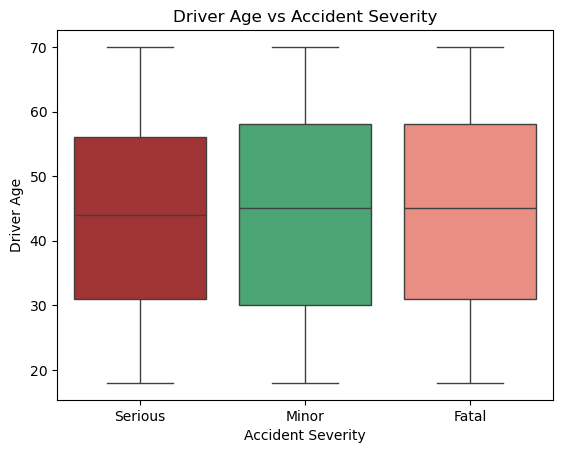

In [64]:
sns.boxplot(x='Accident Severity', y='Driver Age',
            data=df, palette=['FireBrick','MediumSeaGreen','Salmon'])
plt.title("Driver Age vs Accident Severity")
plt.show()


# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'"> Driver ages are spread across all accident severity categories, but the distributions differ slightly. Serious accidents cover a wide age range, minor accidents are more concentrated among younger drivers, and fatal accidents show density in middle‑aged groups.</span>


***

# <span style="color:olive; font-size:25px; font-family:'Times New Roman'">Yearly Accident Counts :</span>
<img src="C:\Users\menon\Downloads\35.jpg" style="width:500px;height:200px"/>

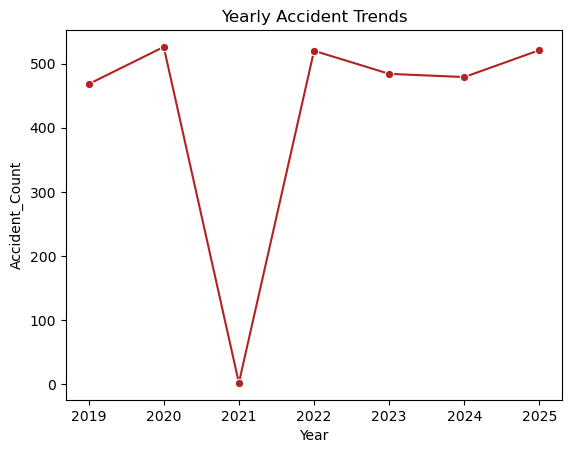

In [65]:
yearly = df.groupby('Year').size().reset_index(name='Accident_Count')
sns.lineplot(x='Year', y='Accident_Count', data=yearly, marker='o', color='firebrick')
plt.title("Yearly Accident Trends")
plt.show()

# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Accidents dropped sharply in 2021 beacuse of lockdown effect, then quickly rose again in 2022 and stayed steady afterward. This shows that 2021 was an unusual year compared to the rest.</span>


***

# <span style="color:Darkcyan; font-size:30px; font-family:'Times New Roman'">Multivariate Analysis :</span>

# <span style="color:chocolate; font-size:25px; font-family:'Times New Roman'">Correlation Heatmap :</span>
<img src="C:\Users\menon\Downloads\36.jpg" style="width:500px;height:200px"/>

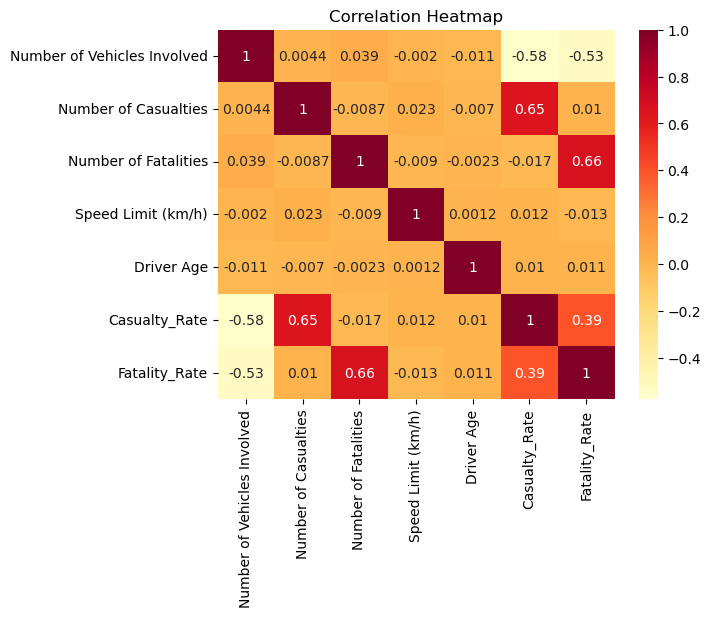

In [66]:
corr = df[['Number of Vehicles Involved','Number of Casualties',
           'Number of Fatalities','Speed Limit (km/h)',
           'Driver Age','Casualty_Rate','Fatality_Rate']].corr()
sns.heatmap(corr, annot=True, cmap='YlOrRd')
plt.title("Correlation Heatmap")
plt.show()

# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Casualty rate and fatality rate are strongly linked to different accident outcomes,Casualty Rate shows a strong positive correlation with the number of casualties (0.65) and a moderate positive correlation with fatality rate (0.39). This means higher casualty rates tend to align with more injuries and also somewhat with fatalities.Fatality Rate is strongly correlated with the number of fatalities (0.66), confirming that it’s an indicator of deadly accidents.Number of vehicles involved has a negative correlation with both casualty rate (-0.58) and fatality rate (-0.53). This suggests that multi‑vehicle accidents may spread the impact, leading to proportionally fewer casualties or fatalities per accident compared to single vehicle crashes.Speed limit and driver age show almost no meaningful correlation with casualties or fatalities in this dataset, implying other factors (like road and weather conditions) play a bigger role.severity outcomes (casualties and fatalities) are more strongly driven by accident rates themselves than by speed limits or driver age, and single‑vehicle crashes tend to be more dangerous per accident than multi‑vehicle ones.</span>






***

# <span style="color:chocolate; font-size:25px; font-family:'Times New Roman'">Casualty & Fatality Rates by Weather Conditions :</span>
<img src="C:\Users\menon\Downloads\37.jpg" style="width:500px;height:200px"/>

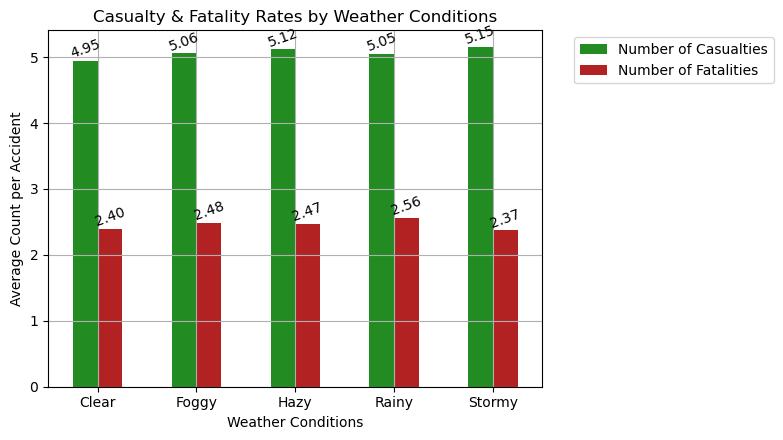

In [17]:
weather_pivot = pd.pivot_table(
    df,
    values=['Number of Casualties', 'Number of Fatalities'],
    index='Weather Conditions',
    aggfunc='mean'
)

weather_pivot
weather_pivot.plot(
    kind='bar',
    figsize=(8,4.5),
     color=['forestgreen','firebrick']
)

plt.xlabel('Weather Conditions')
plt.ylabel('Average Count per Accident')
plt.title('Casualty & Fatality Rates by Weather Conditions')
plt.grid('True')
plt.xticks(rotation=0)
plt.legend( bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f', label_type='edge',rotation=20
)

plt.show()

# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">In clear weather, both casualty and fatality rates are relatively lower, showing safer outcomes.Under rainy and stormy conditions, casualty rates rise noticeably, while fatalities also increase, though at a smaller scale.Foggy and hazy conditions show moderate casualty levels but still maintain a clear gap from fatalities, and visibility issues contribute more to injuries than deaths. Bad weather increases the risk of casualties and raises fatality compared to clear conditions.
</span>

***

# <span style="color:darkviolet; font-size:25px; font-family:'Times New Roman'">Subplots :</span>

# <span style="color:chocolate; font-size:25px; font-family:'Times New Roman'">Severity vs Weather & Road Type :</span>
<img src="C:\Users\menon\Downloads\38.jpg" style="width:500px;height:200px"/>

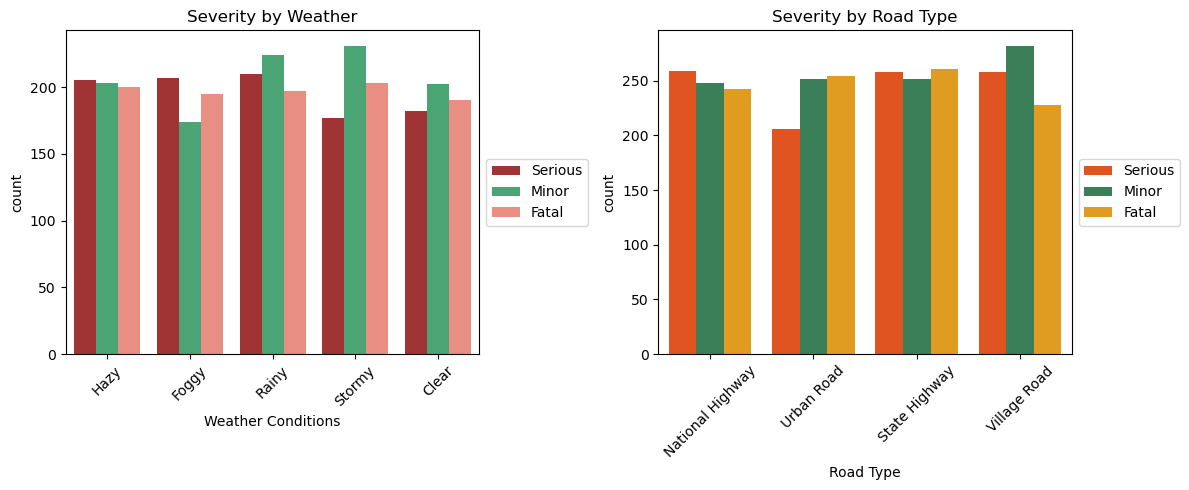

In [69]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.countplot(x='Weather Conditions', hue='Accident Severity', data=df, ax=axes[0], palette=['FireBrick','MediumSeaGreen', 'Salmon'])
axes[0].set_title("Severity by Weather")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
sns.countplot(x='Road Type', hue='Accident Severity', data=df, ax=axes[1], palette=['orangered','seagreen','orange'])
axes[1].set_title("Severity by Road Type")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Accident severity varies noticeably with environmental and infrastructural factors:</span><span style="color:Black; font-size:20px; font-family:'Times New Roman'">Under clear weather, minor accidents dominate, while in rainy or stormy conditions, the share of serious and fatal accidents rises. This suggests that poor weather amplifies accident severity</span>
<span style="color:Black; font-size:20px; font-family:'Times New Roman'">On national and state highways, serious accidents are more frequent compared to urban or village roads, indicating that higher‑speed, high‑traffic roads carry greater risk of severe outcomes.</span>
<span style="color:Black; font-size:20px; font-family:'Times New Roman'">Bad weather and high‑speed road types are linked to more serious accidents, while clear weather and urban/village roads tend to see more minor incidents.</span>




***

# <span style="color:chocolate; font-size:25px; font-family:'Times New Roman'">Severity by Road condition and Weather :</span>
<img src="C:\Users\menon\Downloads\41.jpg" style="width:400px;height:200px"/>

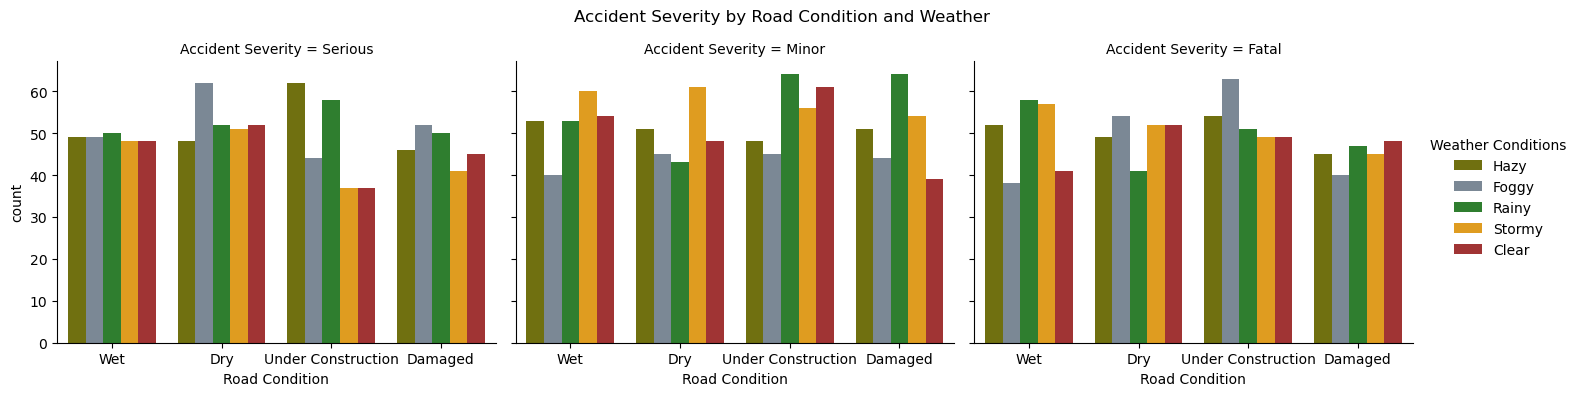

In [29]:
sns.catplot(
    data=df,
    x="Road Condition",
    hue="Weather Conditions",
    col="Accident Severity",
    kind="count",
    height=4,
    aspect=1.2,
    palette=['olive','lightslategray','forestgreen','orange','firebrick']

)
plt.subplots_adjust(top=0.85)
plt.suptitle("Accident Severity by Road Condition and Weather")
plt.show()


# <span style="color:mediumvioletred; font-size:25px; font-family:'Times New Roman'">Insight : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Accidents tend to gather more under poor road conditions combined with adverse weather. Wet or damaged roads with rainy or stormy weather show noticeably higher accident counts compared to clear weather on dry roads.This tells that road maintenance and weather awareness together play a critical role in accident prevention—it’s not about one factor, but the combination that amplifies risk.</span>


***

# <span style="color:crimson; font-size:35px; font-family:'Times New Roman'">Summary :</span>

# <span style="color:green; font-size:25px; font-family:'Times New Roman'">Accident Severity : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Minor accidents are the most common, but serious and fatal accidents occur at nearly the same frequency.This means that while most crashes are not severe, the share of high‑severity accidents is still large enough to be a serious concern.</span>
# <span style="color:green; font-size:25px; font-family:'Times New Roman'">Driver Age : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Accidents happen across all age groups, but younger drivers (20–30 years) and middle‑aged drivers (around 50 years) are more involved.Inexperienced younger drivers and experienced middle‑aged drivers both show higher accident counts compared to other age ranges.</span>
# <span style="color:green; font-size:25px; font-family:'Times New Roman'">Speed Limits : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Most accidents occur at moderate speed limits (50–80 km/h).Crashes also happen at lower speeds (30–40 km/h) and higher speeds (above 100 km/h).This shows that accidents are not limited to extreme speeds—both city driving and highway driving contribute.</span>
# <span style="color:green; font-size:25px; font-family:'Times New Roman'">Vehicle Types : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Accidents are fairly evenly spread across vehicle types, but trucks, buses, and auto‑rickshaws show slightly higher counts.Larger vehicles and public transport modes may pose higher risks due to frequent use and greater exposure.</span>
# <span style="color:green; font-size:25px; font-family:'Times New Roman'">Gender Distribution : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Male and female drivers are almost equally involved, with female drivers slightly higher (52.1%).This suggests that road safety risks affect both genders nearly equally.</span>

# <span style="color:green; font-size:25px; font-family:'Times New Roman'">Fatalities : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Most accidents result in zero fatalities, with only a small proportion involving deaths.Fatal accidents are rare compared to non‑fatal ones, but they still demand attention.</span>

# <span style="color:green; font-size:25px; font-family:'Times New Roman'">Road Types : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">National Highways have the highest average casualties per accident.Village Roads have the lowest, while Urban Roads and State Highways fall in between.High‑traffic roads carry greater risks due to speed and congestion.</span>

# <span style="color:green; font-size:25px; font-family:'Times New Roman'">Trends Over Time : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Fatalities dropped sharply in 2021 (likely due to lockdowns), then spiked in 2022 and stayed steady afterward.This shows that external factors like reduced traffic can strongly affect accident outcomes.</span>

# <span style="color:green; font-size:25px; font-family:'Times New Roman'">Road Safety Controls : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Signboards are linked with the highest number of accidents compared to police checkposts and signals.Static signboards may be less effective than active controls like signals or police presence.</span>

# <span style="color:green; font-size:25px; font-family:'Times New Roman'">Alcohol Involvement : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Alcohol increases the chances of serious and fatal accidents.Minor accidents are more common when alcohol is not involved.Strict action against drunk driving is essential.</span>
# <span style="color:green; font-size:25px; font-family:'Times New Roman'">Correlation Insights : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Casualty rate is strongly linked with the number of injuries and moderately linked with fatalities.Fatality rate is strongly linked with deaths.Multi‑vehicle accidents show fewer casualties per crash compared to single‑vehicle accidents.Speed limit and driver age show little correlation with casualties or fatalities, meaning other factors (road and weather) matter more.</span>
# <span style="color:green; font-size:25px; font-family:'Times New Roman'">Weather Conditions : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Clear weather shows lower casualty and fatality rates.Rainy and stormy conditions increase both casualties and fatalities.Foggy and hazy conditions raise injuries more than deaths.Poor weather amplifies accident severity.</span>
# <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Accidents are shaped by a mix of environmental factors (road condition, weather, speed limits) and human factors (driver age, alcohol, vehicle type). Minor accidents are most common, but serious and fatal accidents occur often enough to demand strong safety measures.</span>

***

# <span style="color:crimson; font-size:35px; font-family:'Times New Roman'">Suggestions :</span>

# <span style="color:blueviolet; font-size:25px; font-family:'Times New Roman'">Road and Infrastructure : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Build wide roads to reduce traffic congestion.Make separate lanes for bikes, cars, and heavy vehicles.Regularly repair and maintain roads.Install clear traffic signs at the right places.Use bright and reflective sign boards for night visibility.Ensure traffic signals are working properly at all junctions.Add extra lighting near schools, hospitals, and crossings.Build footpaths for people to walk safely.Provide zebra crossings and pedestrian signals.Construct foot overbridges or underpasses on busy roads.Install speed breakers near schools and residential areas.Avoid roadside parking on narrow roads.Provide proper parking spaces to reduce traffic blockage.Install CCTV cameras to monitor traffic.Use speed detection cameras to control over-speeding.</span>
# <span style="color:blueviolet; font-size:25px; font-family:'Times New Roman'">Weather Based Safety Measures : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Send SMS alerts or radio alerts about dangerous weather.Install digital boards to display weather warnings.</span>
# <span style="color:blueviolet; font-size:25px; font-family:'Times New Roman'">Alcohol Control : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Conduct regular drink-and-drive checks.Impose heavy fines and strict punishment for drunk driving.Suspend or cancel driving licenses for repeat offenders.Increase penalties for accidents caused by drunk driving.Encourage use of taxis, public transport, or ride-sharing after drinking.
# <span style="color:blueviolet; font-size:25px; font-family:'Times New Roman'">Avoid Driving When Tired : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Do not drive if you feel sleepy.Take short breaks during long trips.</span>
# <span style="color:blueviolet; font-size:25px; font-family:'Times New Roman'">Speed Management : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Fix speed limits based on road type (highway, city, school zone).Display speed limit boards clearly.Install speed cameras on highways and busy roads.Conduct regular police speed checks.Install speed breakers near schools and residential areas.</span>
# <span style="color:blueviolet; font-size:25px; font-family:'Times New Roman'">Vehicle Management : </span> <span style="color:Black; font-size:20px; font-family:'Times New Roman'">Check brakes, tyres, lights, and mirrors regularly.Ensure vehicles are serviced on time.Do not overload trucks, buses, or cars.Follow legal weight limits.Do not overload trucks, buses, or cars.Follow legal weight limits.Encourage vehicles with airbags and ABS brakes.Use seat belts and helmets properly.Restrict heavy vehicles during peak hours in cities.</span>
<img src="C:\Users\menon\Downloads\42.jpg" style="width:900px;height:350px"/>

***

<img src="C:/Users/menon/Downloads/47.jpg" 
     style="width:400px; height:200px; display:block; margin-left:auto; margin-right:auto;" 
     alt="Accident Chart" />


***